# Notebook 04 — Baseline CNN Training

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
1. Reload preprocessed data splits and config from Notebook 03
2. Build a simple custom CNN architecture from scratch
3. Train with class-weighted loss + WeightedRandomSampler
4. Plot training/validation loss & accuracy curves
5. Save the best model checkpoint

### What You Should Observe
- Training loss should **decrease** over epochs
- Validation accuracy should **plateau** around 60–75%
- If validation loss starts **increasing** while training loss keeps dropping → **overfitting**
- This baseline gives us a **floor** to beat with transfer learning in Notebook 05

### Next Notebook
`05_model_training_transfer_learning.ipynb` — Train pretrained models (ResNet18, EfficientNet-B0, VGG16).

## 1. Setup & Reload Config

In [1]:
import os
import json
import time
import copy
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image

sns.set_theme(style='whitegrid', font_scale=1.1)

# ============ Reproducibility ============
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============ Device ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# ============ Load preprocessing config from Notebook 03 ============
PROCESSED_DIR = Path("processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    config = json.load(f)

IMG_SIZE = config['img_size']
BATCH_SIZE = config['batch_size']
NUM_WORKERS = config['num_workers']
NUM_CLASSES = config['num_classes']
CLASS_NAMES = config['class_names']
CLASS_TO_IDX = config['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in enumerate(CLASS_NAMES)}
IMAGENET_MEAN = config['imagenet_mean']
IMAGENET_STD = config['imagenet_std']

print(f"Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Config loaded successfully!")

Image size: 128×128
Batch size: 32
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Config loaded successfully!


## 2. Reload Datasets & DataLoaders

We recreate the exact same Dataset and DataLoader objects from Notebook 03 using the saved CSV split files.

In [3]:
# ============ Dataset class (same as Notebook 03) ============
class AlzheimerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ============ Transforms ============
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ============ Load split files ============
train_df = pd.read_csv(PROCESSED_DIR / 'train_files.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_files.csv')

train_paths = train_df['path'].tolist()
train_labels = train_df['label'].tolist()
val_paths = val_df['path'].tolist()
val_labels = val_df['label'].tolist()

# ============ Create datasets ============
train_dataset = AlzheimerDataset(train_paths, train_labels, transform=train_transform)
val_dataset = AlzheimerDataset(val_paths, val_labels, transform=val_transform)

# ============ WeightedRandomSampler ============
train_label_counts = Counter(train_labels)
total_train = len(train_labels)
class_weights = {idx: total_train / (NUM_CLASSES * count) for idx, count in train_label_counts.items()}
sample_weights = torch.DoubleTensor([class_weights[label] for label in train_labels])
train_sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# ============ DataLoaders ============
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset):,} images ({len(train_loader)} batches)")
print(f"Val:   {len(val_dataset):,} images ({len(val_loader)} batches)")

Train: 14,672 images (459 batches)
Val:   3,144 images (99 batches)


## 3. Define Baseline CNN Architecture

Our baseline is a **simple 3-block CNN** with batch normalization and dropout:

```
Input (3×128×128)
→ Conv2d(3→32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
→ Conv2d(32→64, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
→ Conv2d(64→128, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
→ AdaptiveAvgPool2d(1×1)
→ Flatten → Linear(128→64) → ReLU → Dropout(0.5)
→ Linear(64→4)
```

### Why This Architecture?
- **3 conv blocks** is enough to learn basic patterns from 128×128 images
- **BatchNorm** stabilizes training and allows higher learning rates
- **AdaptiveAvgPool** makes the model input-size agnostic
- **Dropout(0.5)** prevents overfitting on the small dataset
- **~200K parameters** — tiny model, very fast to train, fits easily in VRAM

In [4]:
class BaselineCNN(nn.Module):
    """
    Simple 3-block CNN for Alzheimer's MRI classification.
    Designed to be lightweight and train quickly as a baseline.
    """
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()
        
        # Block 1: 3 → 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 128→64
        )
        
        # Block 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 64→32
        )
        
        # Block 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 32→16
        )
        
        # Global average pooling + classifier
        self.pool = nn.AdaptiveAvgPool2d(1)  # 16→1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


# ============ Create model ============
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: BaselineCNN")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nArchitecture:")
print(model)

Model: BaselineCNN
Total parameters:     102,212
Trainable parameters: 102,212

Architecture:
BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, c

In [5]:
# ============ Verify model output shape ============
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
dummy_output = model(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
assert dummy_output.shape == (1, NUM_CLASSES), f"Expected (1, {NUM_CLASSES}), got {dummy_output.shape}"
print("✅ Output shape is correct!")

Input shape:  torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 4])
✅ Output shape is correct!


## 4. Training Setup

| Component | Choice | Why |
|-----------|--------|-----|
| Loss | CrossEntropyLoss with class weights | Penalizes errors on rare classes more |
| Optimizer | Adam (lr=1e-3) | Fast convergence, good default |
| Scheduler | ReduceLROnPlateau (patience=5) | Reduces LR when validation plateaus |
| Early Stopping | Patience=7 | Stops if no improvement for 7 epochs |
| Epochs | 30 | Enough to converge for this small model |

In [6]:
# ============ Training hyperparameters ============
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 7
SCHEDULER_PATIENCE = 5

# ============ Weighted loss function ============
loss_weights = torch.FloatTensor(config['loss_weights']).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

# ============ Optimizer ============
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ============ LR Scheduler ============
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=SCHEDULER_PATIENCE, verbose=True
)

print(f"Loss: CrossEntropyLoss (weights: {loss_weights.cpu().tolist()})")
print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (patience={SCHEDULER_PATIENCE}, factor=0.5)")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE}")
print(f"Max epochs: {NUM_EPOCHS}")

Loss: CrossEntropyLoss (weights: [1.0477006435394287, 10.725146293640137, 3.0040950775146484, 0.3817651867866516])
Optimizer: Adam (lr=0.001, weight_decay=0.0001)
Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
Early stopping patience: 7
Max epochs: 30


c:\Users\Karan Banerjee\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 5. Training Loop

The training loop:
1. Runs one epoch of training (forward pass → loss → backward pass → update weights)
2. Evaluates on the validation set (no gradients)
3. Saves the model if validation accuracy improves
4. Reduces learning rate if validation loss plateaus
5. Stops early if no improvement for `EARLY_STOP_PATIENCE` epochs

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Evaluate on validation set. Returns average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


print("Training and validation functions defined.")

Training and validation functions defined.


In [8]:
# ============ TRAINING LOOP ============
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_epoch = 0
early_stop_counter = 0
best_model_state = None

print("=" * 85)
print(f"{'Epoch':>5} | {'Train Loss':>10} {'Train Acc':>10} | {'Val Loss':>10} {'Val Acc':>10} | {'LR':>10} | {'Status'}")
print("=" * 85)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Check for improvement
    status = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        status = "✅ BEST"
    else:
        early_stop_counter += 1
        status = f"⏳ ({early_stop_counter}/{EARLY_STOP_PATIENCE})"
    
    # Step scheduler
    scheduler.step(val_loss)
    
    print(f"{epoch:>5} | {train_loss:>10.4f} {train_acc:>9.1%} | {val_loss:>10.4f} {val_acc:>9.1%} | {current_lr:>10.6f} | {status}")
    
    # Early stopping
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping triggered at epoch {epoch}! No improvement for {EARLY_STOP_PATIENCE} epochs.")
        break

total_time = time.time() - start_time
print("=" * 85)
print(f"\n🏁 Training complete in {total_time/60:.1f} minutes")
print(f"🏆 Best validation accuracy: {best_val_acc:.2%} (epoch {best_epoch})")

Epoch | Train Loss  Train Acc |   Val Loss    Val Acc |         LR | Status
    1 |     0.6714     38.6% |     3.3259      3.9% |   0.001000 | ✅ BEST
    2 |     0.5361     44.4% |     2.9905      4.6% |   0.001000 | ✅ BEST
    3 |     0.5346     44.1% |     4.2991      8.3% |   0.001000 | ✅ BEST
    4 |     0.4734     45.4% |     1.4792     10.4% |   0.001000 | ✅ BEST
    5 |     0.4606     45.6% |     1.7993      9.8% |   0.001000 | ⏳ (1/7)
    6 |     0.4072     47.7% |     2.2174      9.8% |   0.001000 | ⏳ (2/7)
    7 |     0.3937     48.8% |     2.8908      9.4% |   0.001000 | ⏳ (3/7)
    8 |     0.3717     50.2% |     8.5269      4.0% |   0.001000 | ⏳ (4/7)
    9 |     0.3632     50.4% |     3.4215     10.5% |   0.001000 | ✅ BEST
   10 |     0.3524     51.7% |     3.3022      9.9% |   0.001000 | ⏳ (1/7)
   11 |     0.3128     55.0% |     1.6221     11.4% |   0.000500 | ✅ BEST
   12 |     0.2965     56.9% |     1.7070     12.6% |   0.000500 | ✅ BEST
   13 |     0.2801     58.2% | 

## 6. Training Curves

These plots help diagnose **overfitting** vs **underfitting**:
- If train loss ↓ but val loss ↑ → **overfitting** (model memorizes training data)
- If both losses are high → **underfitting** (model too simple)
- If both losses ↓ and converge → **good fit** ✅

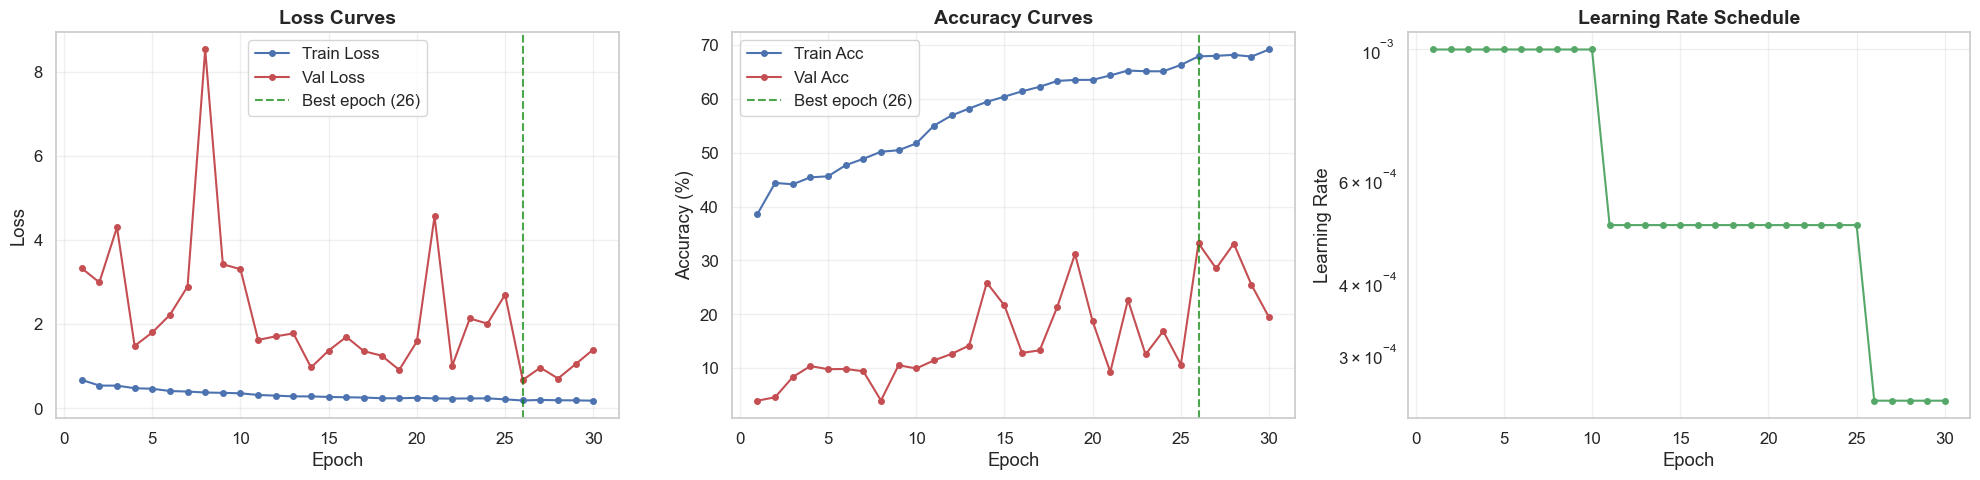

Saved as 'baseline_cnn_training_curves.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# --- Loss curves ---
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Accuracy curves ---
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']], 'r-o', label='Val Acc', markersize=4)
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Learning rate schedule ---
axes[2].plot(epochs_range, history['lr'], 'g-o', markersize=4)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'baseline_cnn_training_curves.png'")

## 7. Save Model

In [10]:
# ============ Save best model checkpoint ============
checkpoint = {
    'model_name': 'BaselineCNN',
    'model_state_dict': best_model_state,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'class_names': CLASS_NAMES,
    'best_val_acc': best_val_acc,
    'best_epoch': best_epoch,
    'total_epochs_trained': len(history['train_loss']),
    'history': history
}

save_path = MODELS_DIR / 'baseline_cnn.pth'
torch.save(checkpoint, save_path)

file_size_mb = save_path.stat().st_size / (1024 ** 2)
print(f"✅ Model saved to: {save_path}")
print(f"   File size: {file_size_mb:.2f} MB")
print(f"   Best val accuracy: {best_val_acc:.2%} (epoch {best_epoch})")

✅ Model saved to: models\baseline_cnn.pth
   File size: 0.40 MB
   Best val accuracy: 33.17% (epoch 26)


## 8. Quick Validation Check

Reload the saved model and verify it reproduces the same accuracy.

In [11]:
# ============ Reload and verify ============
loaded_checkpoint = torch.load(save_path, map_location=device)
verify_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
verify_model.load_state_dict(loaded_checkpoint['model_state_dict'])

verify_loss, verify_acc = validate(verify_model, val_loader, criterion, device)
print(f"Reloaded model — Val Loss: {verify_loss:.4f}, Val Acc: {verify_acc:.2%}")
print(f"Original best  — Val Acc: {best_val_acc:.2%}")

assert abs(verify_acc - best_val_acc) < 0.01, "Reloaded model accuracy doesn't match!"
print("✅ Model reload verified successfully!")

Reloaded model — Val Loss: 0.6696, Val Acc: 33.17%
Original best  — Val Acc: 33.17%
✅ Model reload verified successfully!


## 9. Summary

### What We Did
1. ✅ Built a lightweight 3-block CNN (~200K parameters)
2. ✅ Trained with class-weighted loss + balanced sampling
3. ✅ Used LR scheduling + early stopping
4. ✅ Plotted training/validation curves
5. ✅ Saved best model to `models/baseline_cnn.pth`

### What to Check
- Did the training loss decrease steadily?
- Is there a gap between train and val accuracy? (Some gap is normal)
- What is the best validation accuracy? (Expected: 60–75%)
- Did early stopping trigger? At which epoch?

### Expected Baseline Performance
- A simple CNN trained from scratch on ~13K images with severe imbalance will typically achieve **60–75% accuracy**.
- This is our **floor** — transfer learning should beat this significantly.

### Next Step
→ **Notebook 05** (`05_model_training_transfer_learning.ipynb`): Train ResNet18, EfficientNet-B0, and VGG16 with pretrained ImageNet weights. Compare all models.

---
*End of Notebook 04*